In [ ]:
#HONOURS AIML - MACHINE LEARNING MINI PROJECT.
#DHRUV HARSHAL SHAH.
#SAP ID - 60002230084.
#ROLL NUMBER - E040.
#TE EXTC 1 BATCH H2.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load the dataframes.
import pandas as pd
fraud_df = pd.read_csv('/content/drive/MyDrive/ML HONOURS/ML MINI PROJECT/FRAUD PROTECTION.csv')

# Display the first 5 rows of each dataframe.
display(fraud_df.head())


,user_id,account_holder,user_profile,amount,txn_hour,country,city,new_device,new_payee,merchant_category,channel,is_fraud
0,1,A,Night_Owl,379.895083,22,India,Hyderabad,0,0,Lifestyle,UPI,0
1,1,A,Night_Owl,522.844279,1,India,Hyderabad,0,0,Travel,Card_Online,0
2,1,A,Night_Owl,1957.838016,21,India,Hyderabad,0,1,Lifestyle,Card_Online,0
3,1,A,Night_Owl,1460.174178,23,India,Hyderabad,1,0,Bills,Card_Swipe,0
4,1,A,Night_Owl,943.606278,0,India,Hyderabad,0,0,Fuel,UPI,0


In [ ]:
!pip install pandas numpy scikit-learn


In [ ]:
print(fraud_df.head())
print(fraud_df.shape)

   user_id account_holder user_profile       amount  txn_hour country  \
0        1              A    Night_Owl   379.895083        22   India   
1        1              A    Night_Owl   522.844279         1   India   
2        1              A    Night_Owl  1957.838016        21   India   
3        1              A    Night_Owl  1460.174178        23   India   
4        1              A    Night_Owl   943.606278         0   India   

        city  new_device  new_payee merchant_category      channel  is_fraud  
0  Hyderabad           0          0         Lifestyle          UPI         0  
1  Hyderabad           0          0            Travel  Card_Online         0  
2  Hyderabad           0          1         Lifestyle  Card_Online         0  
3  Hyderabad           1          0             Bills   Card_Swipe         0  
4  Hyderabad           0          0              Fuel          UPI         0  
(3000, 12)


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

df2 = fraud_df.copy()

cat_cols = ["country", "city", "merchant_category", "channel"]
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df2[col] = le.fit_transform(df2[col])
    encoders[col] = le

# Features used for clustering
feature_cols = ["amount", "txn_hour", "country", "city",
                "new_device", "new_payee", "merchant_category", "channel"]

X = df2[feature_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
from sklearn.cluster import KMeans

k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
df2["cluster"] = kmeans.fit_predict(X_scaled)

print("Clusters assigned successfully!")
df2.head()


Clusters assigned successfully!


,user_id,account_holder,user_profile,amount,txn_hour,country,city,new_device,new_payee,merchant_category,channel,is_fraud,cluster
0,1,A,Night_Owl,379.895083,22,0,3,0,0,5,5,0,0
1,1,A,Night_Owl,522.844279,1,0,3,0,0,8,0,0,2
2,1,A,Night_Owl,1957.838016,21,0,3,0,1,5,0,0,3
3,1,A,Night_Owl,1460.174178,23,0,3,1,0,0,1,0,4
4,1,A,Night_Owl,943.606278,0,0,3,0,0,3,5,0,2


In [ ]:
cluster_centers = kmeans.cluster_centers_
cluster_centers


array([[-0.39118856,  0.39144836,  0.        ,  0.68643441, -0.33579703,
        -0.41733475,  0.02148957,  0.13558673],
       [ 2.55459391,  0.06241904,  0.        , -0.55027665, -0.27608916,
        -0.20611158, -0.0778762 , -0.23973431],
       [-0.28413777, -0.70089559,  0.        , -0.98325144, -0.33579703,
        -0.41733475,  0.03229033, -0.15187568],
       [-0.245276  , -0.01244993,  0.        ,  0.00429865, -0.33579703,
         2.39615797, -0.09672473, -0.00364512],
       [-0.18580122, -0.02164572,  0.        ,  0.06811039,  2.97798943,
         0.07361029,  0.03585737,  0.06228723]])

In [ ]:
import numpy as np

# calculate distances from cluster center
def distance_from_center(point, center):
    return np.linalg.norm(point - center)

df2["distance"] = 0

for i in range(len(df2)):
    c = df2.loc[i, "cluster"]
    center = cluster_centers[c]
    point = X_scaled[i]
    df2.at[i, "distance"] = distance_from_center(point, center)

# threshold = mean + 2×std → flexible
cluster_thresholds = {}

for c in range(k):
    dist_vals = df2[df2.cluster == c]["distance"]
    threshold = dist_vals.mean() + 2 * dist_vals.std()
    cluster_thresholds[c] = threshold

cluster_thresholds


/tmp/ipython-input-3185014445.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.542976888702175' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df2.at[i, "distance"] = distance_from_center(point, center)


{0: np.float64(2.4486526153396997),
 1: np.float64(3.077994419860758),
 2: np.float64(2.916660970760722),
 3: np.float64(3.00414263800975),
 4: np.float64(3.4880359919335735)}

In [ ]:
def check_transaction(amount, txn_hour, country, city, new_device, new_payee, merchant_category, channel):

    # encode categorical
    country_e = encoders["country"].transform([country])[0]
    city_e = encoders["city"].transform([city])[0]
    merch_e = encoders["merchant_category"].transform([merchant_category])[0]
    chan_e = encoders["channel"].transform([channel])[0]

    # create dataframe
    row = [[amount, txn_hour, country_e, city_e, new_device, new_payee, merch_e, chan_e]]

    # scale
    row_scaled = scaler.transform(row)

    # predict cluster
    predicted_cluster = kmeans.predict(row_scaled)[0]
    center = cluster_centers[predicted_cluster]

    # compute distance
    dist = np.linalg.norm(row_scaled[0] - center)
    threshold = cluster_thresholds[predicted_cluster]

    # decision
    if dist > threshold:
        decision = "BLOCK"
    else:
        decision = "APPROVE"

    return {
        "cluster": int(predicted_cluster),
        "distance": float(dist),
        "threshold": float(threshold),
        "decision": decision
    }


In [ ]:
print("\n=== ENTER NEW TRANSACTION DETAILS ===\n")

amount = float(input("Enter amount: "))
txn_hour = int(input("Enter hour (0-23): "))
country = input("Country (India/UK/UAE/Singapore/USA): ")
city = input("City: ")
new_device = int(input("New device? (0/1): "))
new_payee = int(input("New payee? (0/1): "))
merchant_category = input("Merchant category: ")
channel = input("Channel (UPI/IMPS/NEFT/RTGS/Card_Online/Card_Swipe): ")

result = check_transaction(amount, txn_hour, country, city, new_device, new_payee, merchant_category, channel)

print("\n===== RESULT =====")
print(result)

if result["decision"]=="BLOCK":
    print("\n⚠️ TRANSACTION BLOCKED: Suspicious pattern detected!")
    print("📩 Simulated SMS Sent:")
    print(f"   'We blocked a suspicious transaction of ₹{amount}. If this was you, call 022-12345678.'")
else:
    print("\n✅ Transaction APPROVED")



=== ENTER NEW TRANSACTION DETAILS ===

Enter amount: 123456789
Enter hour (0-23): 23
Country (India/UK/UAE/Singapore/USA): India
City: Mumbai
New device? (0/1): 1
New payee? (0/1): 1
Merchant category: Grocery
Channel (UPI/IMPS/NEFT/RTGS/Card_Online/Card_Swipe): IMPS

===== RESULT =====
{'cluster': 1, 'distance': 5259.303011310494, 'threshold': 3.077994419860758, 'decision': 'BLOCK'}

⚠️ TRANSACTION BLOCKED: Suspicious pattern detected!
📩 Simulated SMS Sent:
   'We blocked a suspicious transaction of ₹123456789.0. If this was you, call 022-12345678.'


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


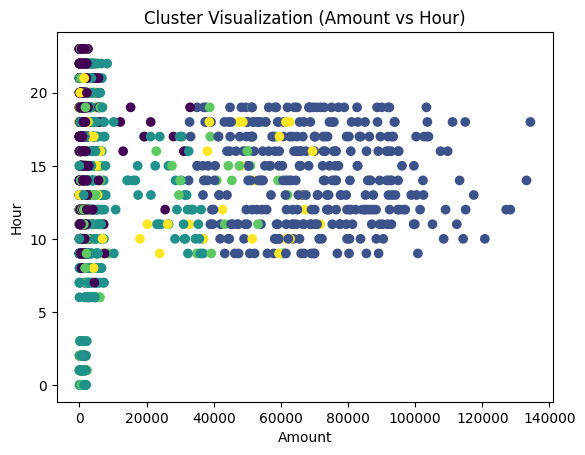

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df2["amount"], df2["txn_hour"], c=df2["cluster"])
plt.xlabel("Amount")
plt.ylabel("Hour")
plt.title("Cluster Visualization (Amount vs Hour)")
plt.show()
